# Load & Explore Data

(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Potability
0    1998
1    1278
Name: count, dtype: int64


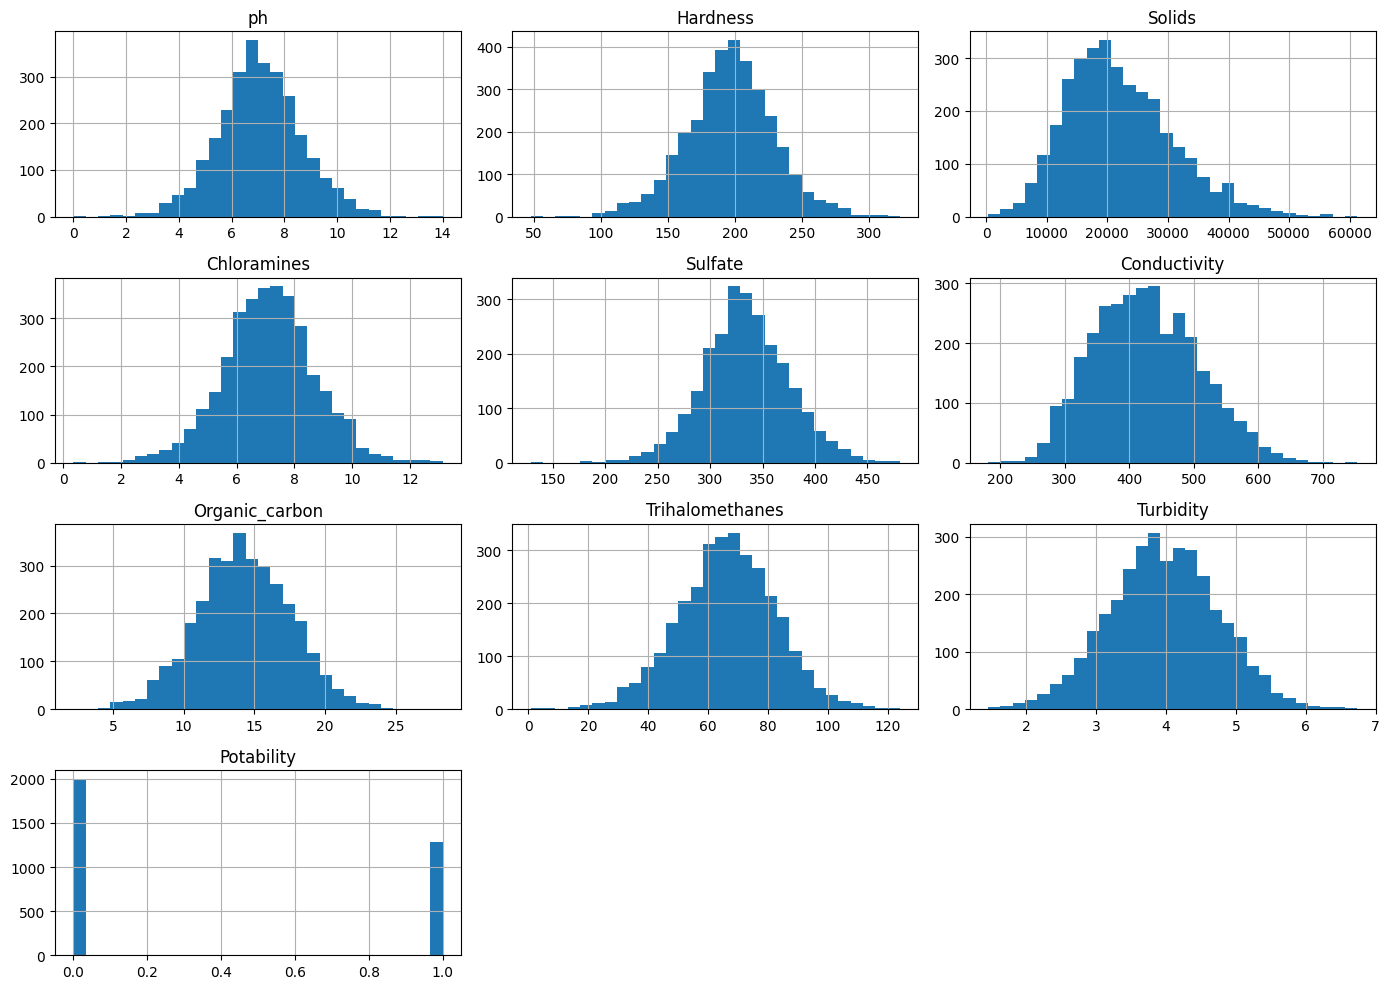

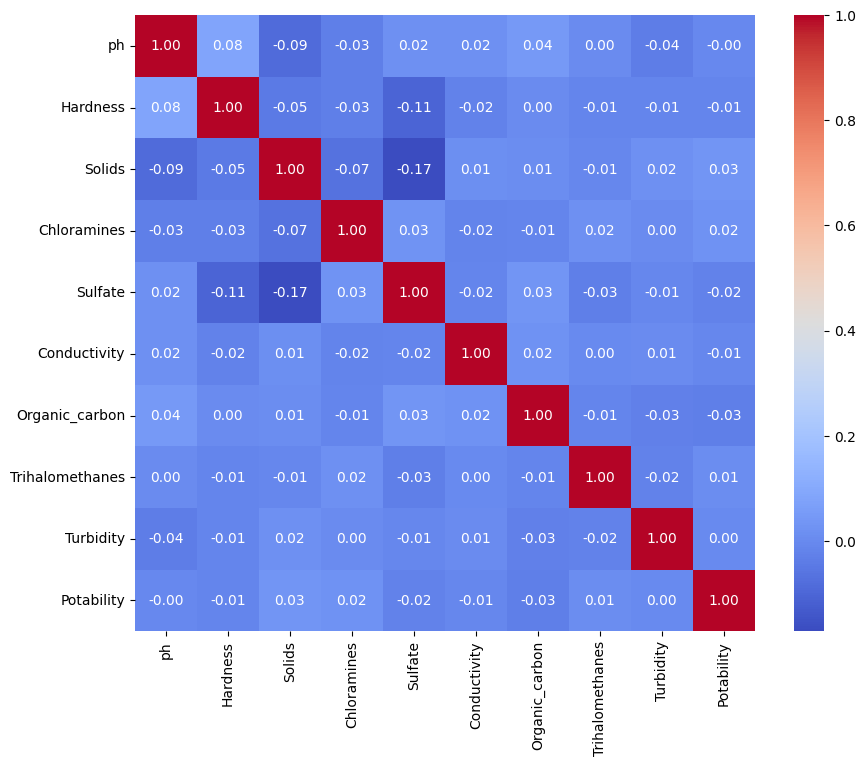

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("water_potability.csv")

print(df.shape)           # (3276, 10)
print(df.isnull().sum())  # pH, Sulfate, Trihalomethanes have nulls
print(df['Potability'].value_counts())  # class imbalance check

# Distribution plots
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout(); plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# Preprocessing + SMOTE
SMOTE - Synthetic Minority Oversampling Technique

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE — fix class imbalance on training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train_res).value_counts())

After SMOTE: Potability
0.0    1598
1.0    1598
Name: count, dtype: int64


Train and Evaluate Model

Import Libraries

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

Initialize Models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42, probability=True)
}

Create Results Storage

In [5]:
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': [],
    'Training Time (s)': [],
    'Prediction Time (s)': []
}

Training Loop

In [6]:
for name, model in models.items():
    print(f"\n--- Training {name} ---")


--- Training Logistic Regression ---

--- Training Random Forest ---

--- Training Gradient Boosting ---

--- Training SVM ---


Model Training

In [7]:
start_time = time.time()
model.fit(X_train_res, y_train_res)
training_time = time.time() - start_time

Prediction

In [8]:
start_time = time.time()
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
prediction_time = time.time() - start_time

Evaluation Metrics

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

Print Results

In [10]:
print(f"{name} Accuracy: {accuracy:.4f}")
print(f"{name} Precision: {precision:.4f}")
print(f"{name} Recall: {recall:.4f}")
print(f"{name} F1-Score: {f1:.4f}")
print(f"{name} ROC-AUC: {roc_auc:.4f}")

SVM Accuracy: 0.6174
SVM Precision: 0.5093
SVM Recall: 0.5352
SVM F1-Score: 0.5219
SVM ROC-AUC: 0.6487


Store Results

In [11]:
results['Model'].append(name)
results['Accuracy'].append(accuracy)
results['Precision'].append(precision)
results['Recall'].append(recall)
results['F1-Score'].append(f1)
results['ROC-AUC'].append(roc_auc)
results['Training Time (s)'].append(training_time)
results['Prediction Time (s)'].append(prediction_time)

Model Comparison

In [12]:
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
display(results_df.sort_values(by='ROC-AUC', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Prediction Time (s)
Model,,,,,,,
SVM,0.617378,0.509294,0.535156,0.521905,0.648691,0.78472,0.111187


# SHAP interpretability

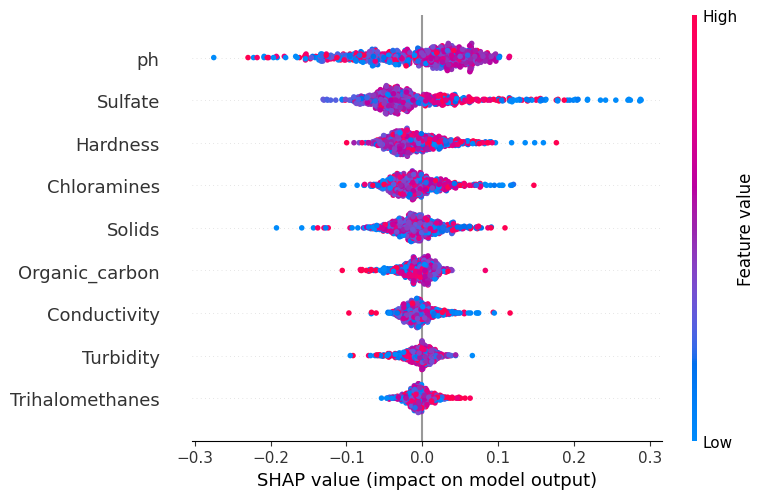

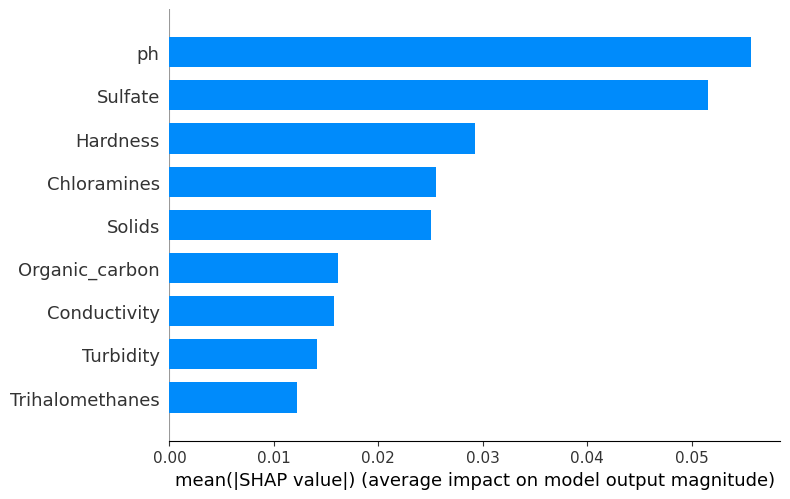

In [13]:
import shap

best_rf = RandomForestClassifier(random_state=42)
best_rf.fit(X_train_res, y_train_res)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

feature_names = list(df.drop("Potability", axis=1).columns)

# Handle both old SHAP (list of arrays) and new SHAP (3D array)
if isinstance(shap_values, list):
    # Old SHAP: shap_values is [class_0_array, class_1_array]
    sv = shap_values[1]
else:
    # New SHAP: shap_values is shape (n_samples, n_features, n_classes)
    sv = shap_values[:, :, 1]

# Summary beeswarm plot
shap.summary_plot(sv, X_test, feature_names=feature_names)

# Bar chart of mean |SHAP|
shap.summary_plot(sv, X_test, feature_names=feature_names, plot_type="bar")

# Save & Deploy

In [14]:
# save_model.py
import pickle
pickle.dump(best_rf, open("rf_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("✅ rf_model.pkl saved successfully")
print("✅ scaler.pkl saved successfully")

✅ rf_model.pkl saved successfully
✅ scaler.pkl saved successfully
